In [1]:
import os
import argparse
from types import SimpleNamespace
from pathlib import Path

import cortex
# os.environ["PATH"] = os.environ["PATH"] + ":/share/nklab/users/pf2477/bin"
# os.environ.setdefault("LANG","C.UTF-8") # (optional) locales, purely to quiet warnings
# os.environ.setdefault("LC_ALL","C.UTF-8")


import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

os.chdir("/engram/nklab/pf2477/brain_decoding/")
from brain_adapter.dataset import nsd_topk_parcel_dataset, get_dominant_roi_per_parcel

In [2]:
import os, re, subprocess as sp
from shutil import which
from cortex.testing_utils import inkscape_version
print("Inkscape version:", inkscape_version())


def has_installed(name):
    return which(name) is not None

def inkscape_version():
    if not has_installed('inkscape'):
        return None

    env = os.environ.copy()
    env.setdefault('LANG', 'C.UTF-8')
    env.setdefault('LC_ALL', 'C.UTF-8')

    # Capture both stdout and stderr so warnings don't hide the version line
    proc = sp.run(
        ['inkscape', '--version'],
        stdout=sp.PIPE,
        stderr=sp.STDOUT,   # merge stderr into stdout
        text=True,
        env=env
    )
    out = proc.stdout or ""

    # Look for "Inkscape <version>"
    m = re.search(r'Inkscape\s+([0-9]+(?:\.[0-9]+)*)', out)
    return m.group(1) if m else None

print(f"Inkscape version: {inkscape_version()}")

Inkscape version: should
Inkscape version: 1.3


In [3]:
!inkscape --version

Setting _INKSCAPE_GC=disable as a workaround for broken libgc
You should not use AppImage in production, but you can speedup the AppImage by following this guide: https://inkscape.org/learn/appimage/

(process:7115): Gtk-WARNING **: 14:56:17.172: Locale not supported by C library.
	Using the fallback 'C' locale.
Unable to init server: Could not connect: Connection refused
Inkscape 1.3 (0e150ed, 2023-07-21)


In [4]:
import shutil, os, subprocess as sp

def robust_inkscape_version():
    env = os.environ.copy()
    env.setdefault('LANG','C.UTF-8'); env.setdefault('LC_ALL','C.UTF-8')
    p = sp.run(['inkscape','--version'], stdout=sp.PIPE, stderr=sp.STDOUT, text=True, env=env)
    m = re.search(r'Inkscape\s+([0-9]+(?:\.[0-9]+)*)', p.stdout or "")
    return m.group(1) if m else '0'   # fallback minimal

import cortex, cortex.svgoverlay as svo
svo.INKSCAPE_VERSION = robust_inkscape_version()
print("Patched INKSCAPE_VERSION =", svo.INKSCAPE_VERSION)

Patched INKSCAPE_VERSION = 1.3


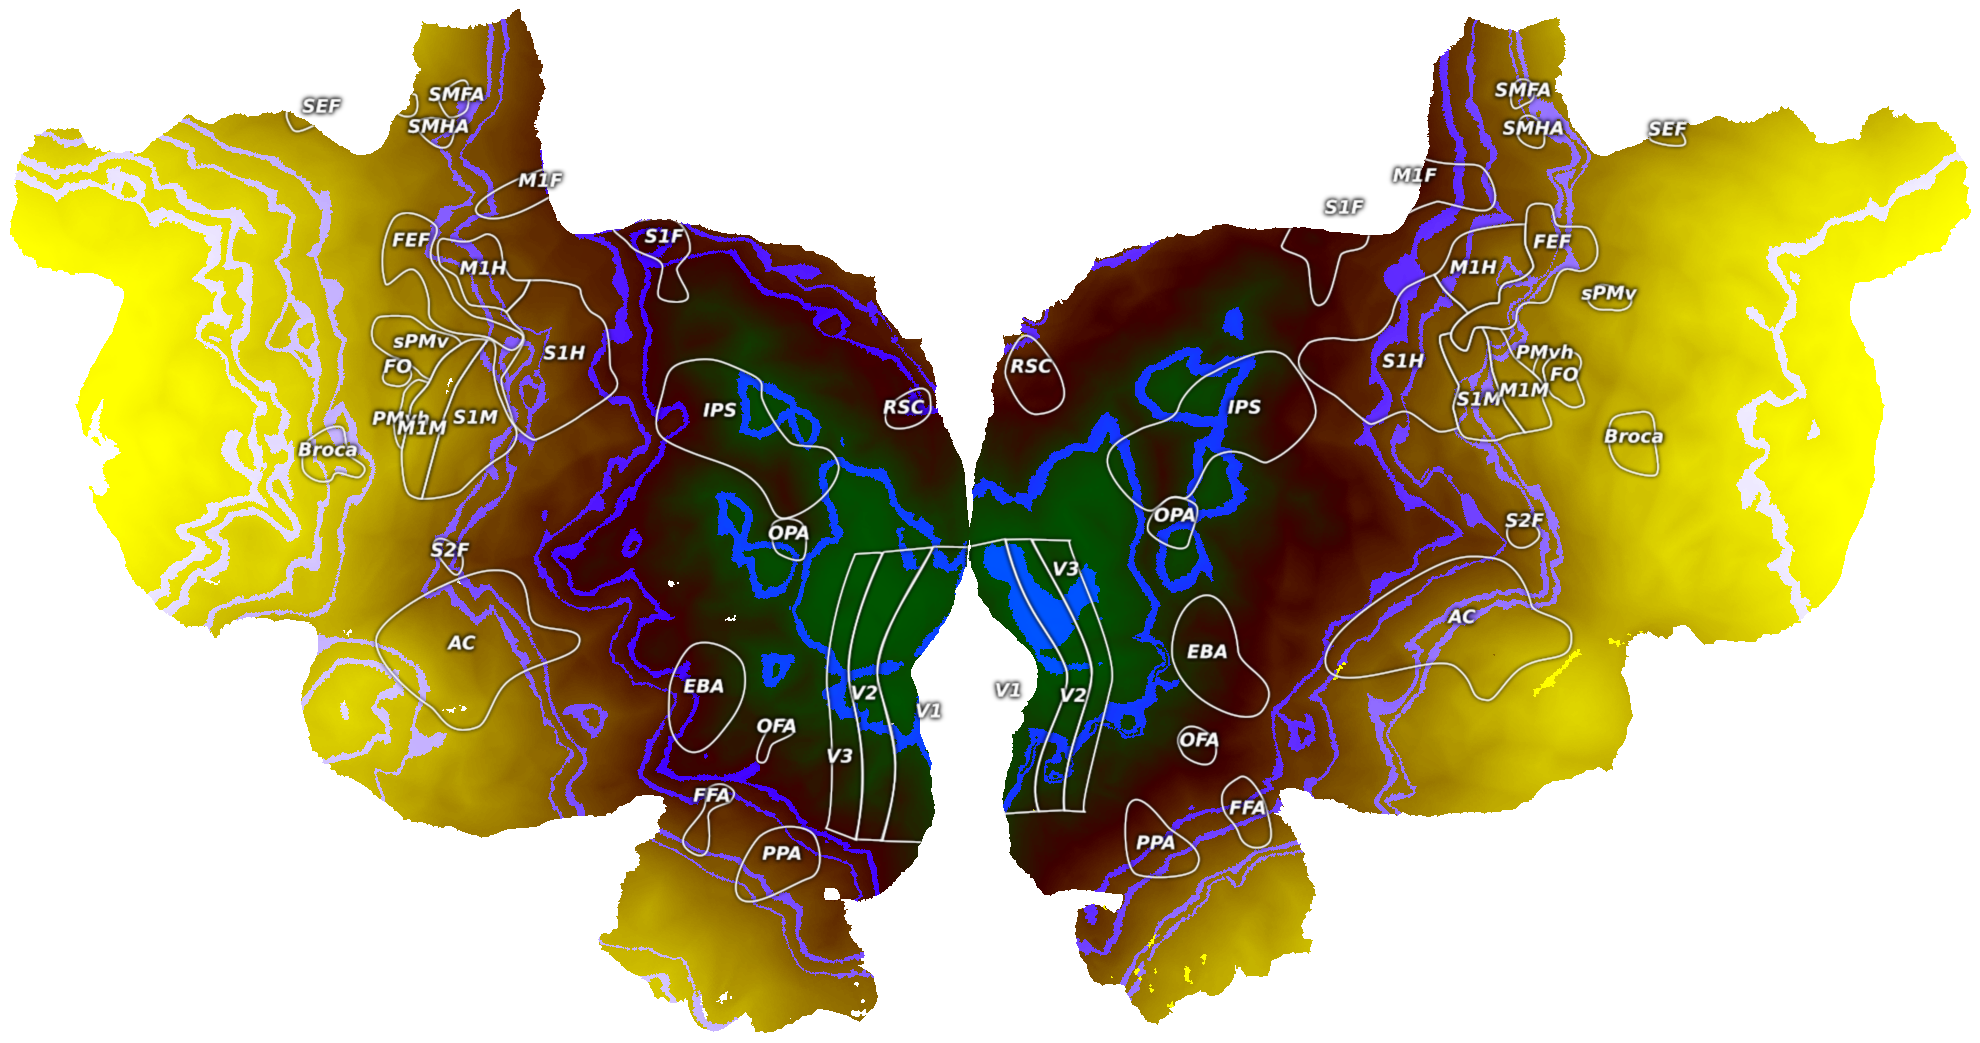

In [11]:
import cortex
import cortex.polyutils
import numpy as np
np.random.seed(1234)
import matplotlib.pyplot as plt

from io import StringIO
from io import BytesIO
from PIL import Image, ImageDraw, ImageFont


subject = 'S1'

# In order to get the number of vertices in this subject's cortical surface
# we have to load in their surfaces and get the number of points in each
surfs = [cortex.polyutils.Surface(*d)
         for d in cortex.db.get_surf(subject, "fiducial")]

# This is the total number of vertices in the left and right hemispheres
num_verts = [s.pts.shape[0] for s in surfs]

# Creating one fake dataset that is basically a gradient across each
# hemisphere based on vertex number
test1 = np.hstack((np.arange(num_verts[0]), np.arange(num_verts[1])))

# Picking a different vertex in each hemisphere to create another fake
# gradient away from that vertex
second_verts = [n / 4 for n in num_verts]
test2 = np.hstack((np.abs(np.arange(num_verts[0]) - second_verts[0]),
                   np.abs(np.arange(num_verts[1]) - second_verts[1])))

# Creating a third dataset that is random stripes
third_verts = np.random.randint(num_verts[0] + num_verts[1], size=(20,))
test3 = np.zeros(num_verts[0] + num_verts[1])
for v in third_verts:
    test3[v-1000: v+1000] = 1

# Scaling the three datasets to be between 0-255
test1_scaled = test1 / np.max(test1) * 255
test2_scaled = test2 / np.max(test2) * 255
test3_scaled = test3 / np.max(test3) * 255

# Creating three cortex.Volume objects with the test data as np.uint8
red = cortex.Vertex(test1_scaled, subject)
green = cortex.Vertex(test2_scaled, subject)
blue = cortex.Vertex(test3_scaled, subject)

# This creates a 2D Vertex object with both of our test datasets for the
# given subject
vertex_data = cortex.VertexRGB(red, green, blue, subject)
with suppress_print():
    cortex.quickshow(vertex_data, with_colorbar=False)
plt.show()

In [12]:
subj=1
args = SimpleNamespace(
        subj=subj,
        backbone_arch="dinov2_q",
        data_dir="/engram/nklab/datasets/natural_scene_dataset/model_training_datasets/neural_data",
        imgs_dir="/engram/nklab/datasets/natural_scene_dataset/nsddata_stimuli/stimuli/nsd",
        parcel_dir="/engram/nklab/algonauts/ethan/whole_brain_encoder/parcels/schaefer",
        hemi=None,
)
args.tokenizer = None
args.gen_size = 512
args.topk = 100
print("Setting up test configuration for subject ", subj)

print("\n" + "="*50)
print("Testing nsd_topk_parcel_dataset (single subject)")
print("="*50)
train_dataset = nsd_topk_parcel_dataset(args, split='train', transform=None, topk=args.topk)
print(len(train_dataset), "samples in the dataset")
print(train_dataset.selected_parcel_idx)
print(len(train_dataset.selected_parcel_idx['lh']), "left hemisphere parcels")
print(len(train_dataset.selected_parcel_idx['rh']), "right hemisphere parcels")

data = train_dataset[0]
print()
print("\nOutput shapes:")
print(f"img_encoder: {data['img_encoder'].shape}")
print(f"img_ipadapter: {data['img_ipadapter'].shape}")
print(f"brain_lh_f: {data['brain_lh_f'].shape}")
print(f"brain_rh_f: {data['brain_rh_f'].shape}")

Setting up test configuration for subject  1

Testing nsd_topk_parcel_dataset (single subject)
Training on subject: 1
9000 samples in the dataset
{'lh': array([  2,  21,  26,  27,  11,   0,   1, 157,   3, 158,  45,  24, 160,
        22,   9,  14, 151,  41,  20,  28,  18, 161,  15, 475,  32, 473,
         8, 159,  23, 163,  31,  17,  25, 166,  44, 164,  19, 467,  10,
       181,  29,  47, 155,   6, 154, 469, 156,   5,  12, 210, 476, 162,
        13, 170,  16, 167,  30,  33, 477,   7, 493, 370, 468, 369, 149,
        56, 377, 367,  46, 171, 213, 165, 172,   4, 153, 481, 495, 152,
       435, 182, 186, 323, 497, 174, 173, 358, 150, 482, 237, 471, 474,
        52, 247, 198, 483, 396, 325, 271, 184, 196]), 'rh': array([ 35,  39,  21,  10, 153,  37, 155,   2,  23,   4,   0, 154,  20,
       152,  42,  19, 151,  15,  36,   8, 302,  13,  43,  28,  41,  29,
       308,  17,  25, 147,   9,  24,  18, 390, 424,  14, 496,   1,  49,
        40, 162, 161, 305, 453, 389,  16, 333, 163, 175,  31, 149, 

In [13]:
neural_data_path = Path(
        "/engram/nklab/datasets/natural_scene_dataset/model_training_datasets/neural_data"
    )
metadata = np.load(
    neural_data_path / f"metadata_sub-{subj:02}.npy", allow_pickle=True
).item()

all_roi_names = list(metadata['lh_rois'].keys())[:24] + list(metadata['rh_rois'].keys())[:24]
print(f' all_roi_names: {all_roi_names}, len: {len(all_roi_names)}')

roi = all_roi_names[0]
print(metadata['lh_rois'][roi])
print(len(metadata['lh_rois'][roi]))
# print([id for id, val in enumerate(metadata['lh_rois'][roi]) if val == True])

min_overlap_threshold = 0.5
dominant_rois = get_dominant_roi_per_parcel(train_dataset, metadata, all_roi_names, min_overlap_threshold=min_overlap_threshold)

print("\n" + "="*50)
print("DOMINANT ROI PER PARCEL (>10% overlap)")
print("="*50)

for hemi in ['lh', 'rh']:
    print(f"\n{hemi.upper()} Hemisphere:")
    cnt = 0
    for parcel_idx, roi_name, overlap, num_voxels in dominant_rois[hemi]:
        if roi_name:
            print(f"Parcel {parcel_idx:3d}: {roi_name:20s} ({overlap:.1%}) in {num_voxels} Schaefer voxels")
            cnt += 1
        else:
            print(f"Parcel {parcel_idx:3d}: No ROI has >= {min_overlap_threshold:.1%} overlap")

    print(f"Total parcels with dominant ROI in {hemi.upper()}: {cnt}")

 all_roi_names: ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'EBA', 'FBA-1', 'FBA-2', 'mTL-bodies', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 'OPA', 'PPA', 'RSC', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'mTL-words', 'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'EBA', 'FBA-1', 'FBA-2', 'mTL-bodies', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 'OPA', 'PPA', 'RSC', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'mTL-words'], len: 48
[False False False ... False False False]
163842
Processing 100 LH parcels with matrix operations...


LH: 100%|██████████| 100/100 [00:00<00:00, 287.59it/s]


Processing 100 RH parcels with matrix operations...


RH: 100%|██████████| 100/100 [00:00<00:00, 287.03it/s]


DOMINANT ROI PER PARCEL (>10% overlap)

LH Hemisphere:
Parcel   2: V1d                  (67.9%) in 184 Schaefer voxels
Parcel  21: EBA                  (100.0%) in 293 Schaefer voxels
Parcel  26: V2d                  (81.8%) in 192 Schaefer voxels
Parcel  27: V3d                  (52.0%) in 204 Schaefer voxels
Parcel  11: V2v                  (55.4%) in 408 Schaefer voxels
Parcel   0: V1v                  (55.0%) in 318 Schaefer voxels
Parcel   1: V1v                  (87.1%) in 233 Schaefer voxels
Parcel 157: EBA                  (95.5%) in 336 Schaefer voxels
Parcel   3: V1d                  (100.0%) in 241 Schaefer voxels
Parcel 158: EBA                  (100.0%) in 85 Schaefer voxels
Parcel  45: PPA                  (100.0%) in 381 Schaefer voxels
Parcel  24: V3d                  (54.0%) in 326 Schaefer voxels
Parcel 160: EBA                  (91.5%) in 201 Schaefer voxels
Parcel  22: V1d                  (69.3%) in 218 Schaefer voxels
Parcel   9: No ROI has >= 50.0% overlap
Parce

In [29]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import cortex

def visualize_parcels_by_roi(
    dataset, metadata, dominant_rois, all_roi_names, subject="fsaverage",
    unlabeled_name="(unlabeled)", unlabeled_color=(0.7,0.7,0.7,1.0),
    with_curvature=True, legend_cols=3
):
    # Ensure subject exists
    if subject not in cortex.db.subjects:
        cortex.download_subject(subject)

    # 1) Collect only matched ROIs (skip None)
    matched_roi_order = []
    seen = set()
    for hemi in ("lh", "rh"):
        for (_pid, roi_name, _overlap, _nvox) in dominant_rois[hemi]:
            if roi_name is not None and roi_name not in seen:
                seen.add(roi_name)
                matched_roi_order.append(roi_name)

    # Compact mapping: 0 = unlabeled (gray), 1..K = matched ROIs
    roi_list = [unlabeled_name] + matched_roi_order
    roi_to_idx = {name: i for i, name in enumerate(roi_list)}

    # 2) Hemisphere sizes
    lh_hemi_size = len(next(iter(metadata['lh_rois'].values())))
    rh_hemi_size = len(next(iter(metadata['rh_rois'].values())))

    # 3) Init labels
    lh_labels = np.zeros(lh_hemi_size, dtype=np.int32)
    rh_labels = np.zeros(rh_hemi_size, dtype=np.int32)

    # 4) Paint parcels
    sel_vox = dataset.get_selected_voxel_indices()
    for hemi, labels in (("lh", lh_labels), ("rh", rh_labels)):
        for pos, (_pid, roi_name, _overlap, _nvox) in enumerate(dominant_rois[hemi]):
            vox = sel_vox[hemi][pos]
            vox = vox.cpu().numpy() if isinstance(vox, torch.Tensor) else np.asarray(vox)
            if vox.size == 0:
                continue
            idx = roi_to_idx.get(roi_name, 0) if roi_name is not None else 0
            labels[vox] = idx

    # 5) Discrete colormap for ONLY matched ROIs (+ unlabeled gray)
    base = plt.cm.tab20(np.linspace(0, 1, 20))
    need = max(1, len(roi_list) - 1)                  # number of matched ROIs
    reps = int(np.ceil(need / 19.0))
    palette = np.vstack([base[1:],] * reps)[:need]    # skip one for variety
    cmap = ListedColormap(np.vstack([np.array(unlabeled_color)[None, :], palette]))

    # 6) Visualize with pycortex (no internal colorbar)
    data = np.append(lh_labels, rh_labels)
    v = cortex.Vertex(data, subject=subject, cmap=cmap, vmin=0, vmax=len(roi_list)-1)
    with suppress_print():
        cortex.quickshow(v, with_curvature=with_curvature, with_colorbar=False)

    # 7) Build a categorical legend showing ONLY matched ROIs
    patches = []
    for i, name in enumerate(roi_list):
        if i == 0:
            continue  # skip unlabeled in legend
        patches.append(mpatches.Patch(color=cmap(i), label=name))

    # Place legend below figure
    fig = plt.gcf()
    if patches:
        fig.legend(
            handles=patches,
            loc="lower center",
            ncol=min(legend_cols, len(patches)),
            fontsize="small",
            frameon=False,
            bbox_to_anchor=(0.5, -0.02)
        )
        plt.subplots_adjust(bottom=0.18)  # make room for legend

    # plt.title("Schaefer parcels colored by matched ROIs (unlabeled in gray)")
    plt.show()


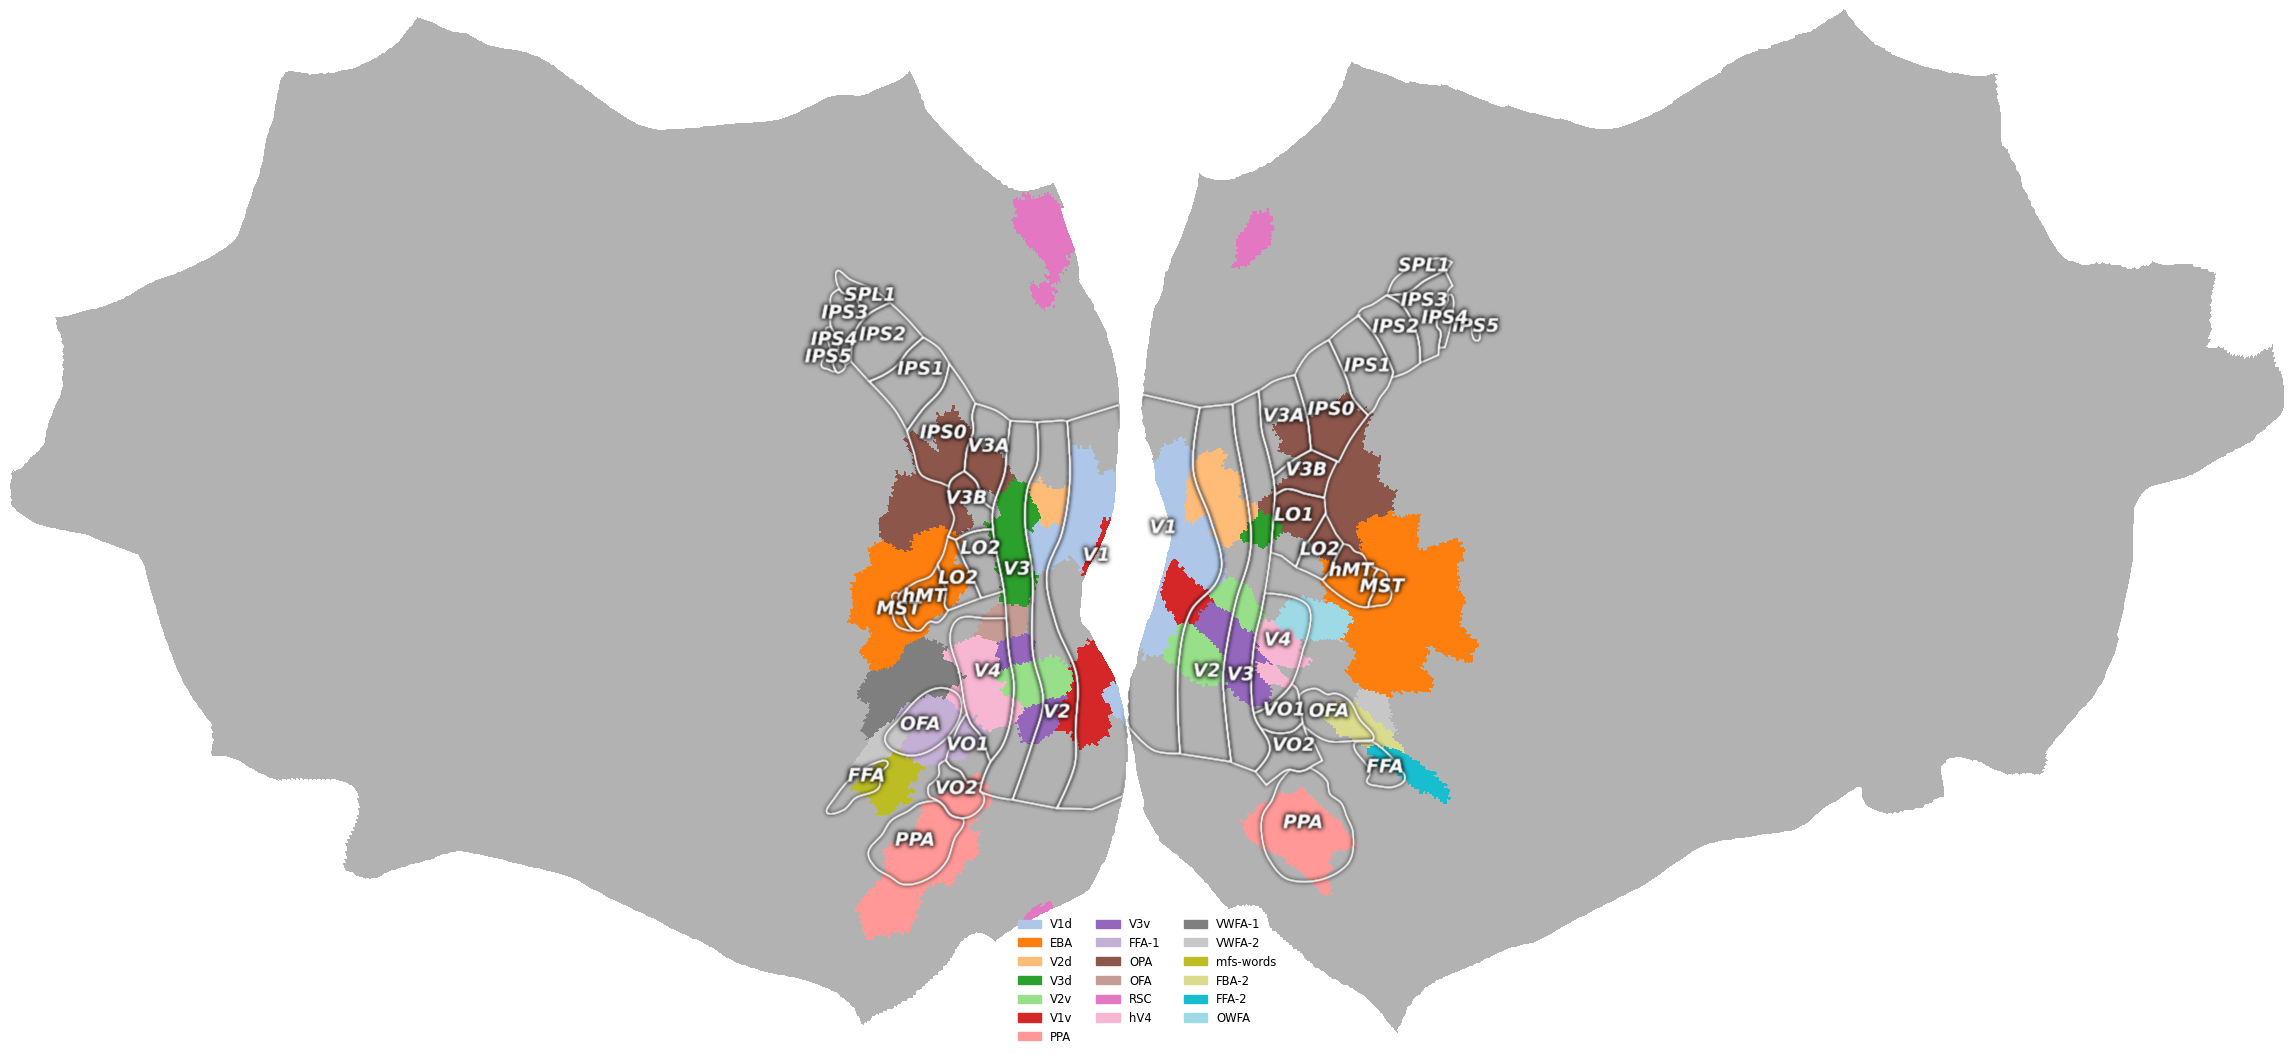

In [30]:
visualize_parcels_by_roi(train_dataset, metadata, dominant_rois, all_roi_names, subject="fsaverage",
                             unlabeled_name="(unlabeled)", unlabeled_color=(0.7,0.7,0.7,1.0))
